# Understanding the Roman WFI Linearity Reference Files

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.2".

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.
    

## Introduction
This notebook covers the three related linearity reference files used by the Roman WFI pipeline:

- **LINEARITY** —The LINEARITY reference file contains pixel-by-pixel polynomial coefficients that map observed DN to linearized DN.
- **INVERSELINEARITY** —  has the same format but contains coefficients for the inverse transformation (linearized DN to observed DN), used internally to simulate individual reads from observed resultants.
- **INTEGRALNONLINEARITY** — contains per-channel lookup tables for correcting integral nonlinearity in the analog-to-digital converter.

These files are critical for accurate flux measurement, especially at high signal levels.

More details about this and other reference files can be found in the [Reference File Information](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/gain_reffile.html#gain-reffile).

### Local Run Settings

If you want to run the notebook in your local machine, refer to the information in [local installation](../../markdown/local-run.md) instructions before proceeding with the notebook. The instructions provide important information about setting up your environment and installing dependencies.

## Imports
Libraries used:
- *astropy* for image normalization
- *copy* for making copies of Python objects
- *crds* for access to calibration reference files
- *matplotlib* and *mpl_toolkits* for plotting images
- *numpy* for array manipulation
- *roman_datamodels* for opening Roman WFI ASDF files
- *os* for operating system functions

In [1]:
import os
from astropy.visualization import simple_norm
import copy

import matplotlib.pyplot as plt
from matplotlib import colors, colormaps as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import roman_datamodels as rdm

### The Calibration Reference Data System (CRDS)

The reference files, developed and validated by STScI’s Science Operations Center, are continually updated as new WFI data become available. For more information about how CRDS works and how it assigns the most appropriate reference file for each calibration step, refer to the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb). 

**IMPORTANT NOTE:** Reference files are a work in progress and will be updated several times before Roman launch. If you notice irregularities or missing information, please understand that they may be a known issue. If you have questions, please contact the [Roman Help Desk](https://romanhelp.stsci.edu).

In [2]:
import crds

Now let's dive into this reference file type.

### Linearity Reference Files

The Roman WFI detectors exhibit classical non-linearity. The pipeline corrects this using polynomial coefficients stored in the `LINEARITY` reference file. The detector is read out through **32 amplifiers**, each covering **128 columns**.

For more details, see the [romancal documentation](https://roman-pipeline.readthedocs.io/en/stable/roman/references_general/linearity_reffile.html) and [Rdox documentation](https://roman-docs.stsci.edu/data-handbook/roman-wfi-data-pipelines/exposure-level-pipeline#ExposureLevelPipeline-linearity) for the Linearity Correction.

Before proceeding, let's check the environmental variables set for CRDS

In [3]:
print(f"CRDS server location: {os.environ.get('CRDS_SERVER_URL')}")
print(f"CRDS context file: {os.environ.get('CRDS_CONTEXT')}")

CRDS server location: https://roman-crds.stsci.edu
CRDS context file: roman-edit


If we want to change the context, we can do it in the next cell. In this case, we choose context `roman_0055.pmap`.

In [4]:
os.environ['CRDS_CONTEXT']='roman_0055.pmap'

### Retrieving Reference Files

As you run the exposure pipeline, the most up-to-date reference files will be automatically selected for each step. However, if you would like to use a specific reference file, retrieve it using the `CRDS` Python API and feed it to the Exposure Level Pipeline, see the notebook [Understanding CRDS and How to Select Calibration Reference files](crds_reference_files.ipynb) for more details.  

For the linearity files in particular, the keywords that will identify the best reference file to use are:

- ROMAN.META.INSTRUMENT.NAME
- ROMAN.META.INSTRUMENT.DETECTOR
- ROMAN.META.EXPOSURE.START_TIME

These keywords may be combined into a single dictionary to find and download the file using `crds.getreferences()`.  

In [5]:
meta = {'ROMAN.META.INSTRUMENT.NAME': 'WFI',
        'ROMAN.META.INSTRUMENT.DETECTOR': 'WFI01',
        'ROMAN.META.EXPOSURE.START_TIME': '2026-01-01 00:00:00'
       }

ref_files = crds.getreferences(meta, reftypes=['linearity', 'inverselinearity', 'integralnonlinearity'], observatory='roman')
ref_files

{'linearity': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_linearity_0039.asdf',
 'inverselinearity': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_inverselinearity_0042.asdf',
 'integralnonlinearity': '/home/runner/crds_cache/references/roman/wfi/roman_wfi_integralnonlinearity_0003.asdf'}

### Examining Reference Files

Reference files use `roman_datamodels` just like WFI science data products and can be accessed in the same way (see the tutorial [Working with ASDF](../working_with_asdf/working_with_asdf.ipynb) for more information). Let's take a closer look at the files we retrieved from our `crds.getreferences()` example:

In [6]:
lin     = rdm.open(ref_files['linearity'])
inv_lin = rdm.open(ref_files.get('inverselinearity'))
int_lin = rdm.open(ref_files.get('integralnonlinearity'))

print("=== LINEARITY ===")
lin.info()
print("\n=== INVERSE LINEARITY ===")
if inv_lin: inv_lin.info()
print("\n=== INTEGRAL NONLINEARITY ===")
if int_lin: int_lin.info()

=== LINEARITY ===
root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 5.0.0
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode)
│   ├─0 (ExtensionMetadata) ...
│   ├─1 (ExtensionMetadata) ...
│   ├─2 (ExtensionMetadata) ...
│   └─3 (ExtensionMetadata) ...
└─roman (LinearityRef) # Linearity Correction Reference Schema
  ├─meta (AsdfDictNode) # Common Reference File Metadata Properties
  │ ├─author (str): Timothy Brandt # Author
  │ ├─description (str): Linearity reference file using 5-th order polynomial derived from TVAC1 data. At bo (truncated)
  │ ├─input_units (IrreducibleUnit): DN
  │ ├─instrument (AsdfDictNode) ...
  │ ├─origin (Origin): STSCI # Institution / Organization Name
  │ ├─output_units (IrreducibleUnit): DN
  │ └─4 not shown
  ├─coeffs (NDArrayType) # Linearity Coefficients ...
  └─dq (NDArrayType) # Two Dimensional Data Quality Array for All Re

/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File 'file:///home/runner/crds_cache/references/roman/wfi/roman_wfi_linearity_0039.asdf'was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.0.0' (from package roman_datamodels==0.27.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)
/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File 'file:///home/runner/crds_cache/references/roman/wfi/roman_wfi_inverselinearity_0042.asdf'was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.0.0' (from package roman_datamodels==0.27.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)
/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File 'file:///home/runner/crds_cache/references/roman/wfi/

We see that the LINEARITY and INVERSELINEARITY reference files contain metadata plus a Linearity Coefficients `coeffs` array and a 2D `dq` array.

### Understanding the Amplifier Structure

The WFI detector is divided into **32 amplifiers**, each 128 columns wide. Linearity coefficients are stored or applied per amplifier.

### Visualizing Linearity Coefficients

The linearity is a 5th order polinomial correction.

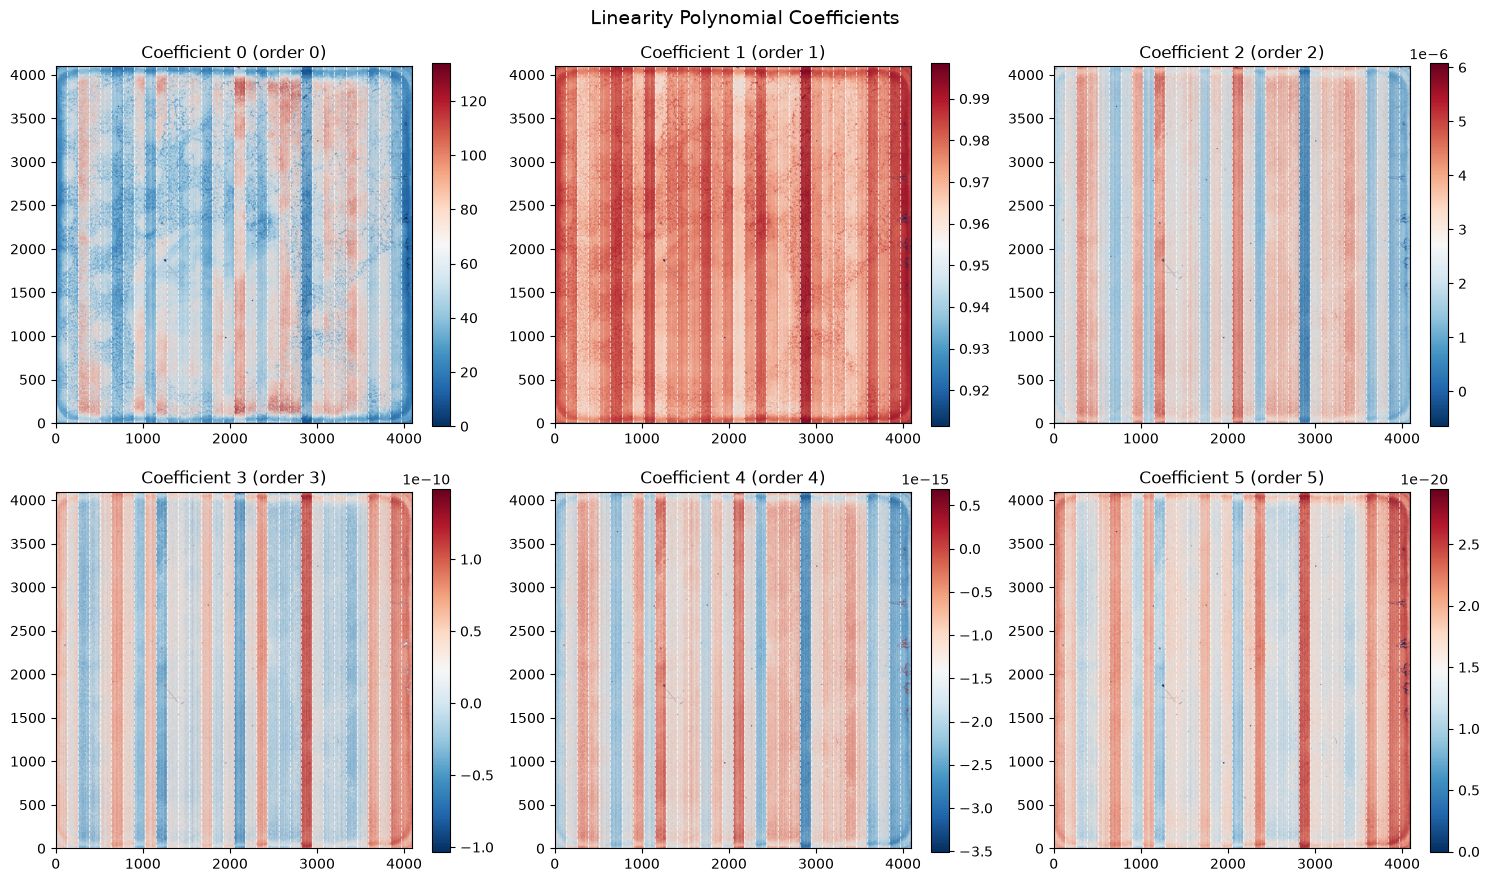

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(15, 9))

for i in range(6):
    ax = axs.flat[i]
    data = lin.coeffs[i]
    norm = simple_norm(data, stretch='linear', percent=99)
    im = ax.imshow(data, cmap='RdBu_r', norm=norm, origin='lower')
    ax.set_title(f'Coefficient {i} (order {i})')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Amplifier boundaries
    for amp in range(1, 32):
        ax.axvline(amp * 128 - 0.5, color='white', ls='--', lw=0.8, alpha=0.6)

plt.suptitle('Linearity Polynomial Coefficients', fontsize=14)
plt.tight_layout()
plt.show()

### INTEGRALNONLINEARITY (Per-Channel Lookup Tables)

Now let's check the Integral Non-Linearity reference file for all channels. Roman WFI has 32 amplifiers (channels). Each channel has a lookup table of length 2048 mapping raw digital numbers to corrected values.

In the plot below, labels are only for the first 10 channels

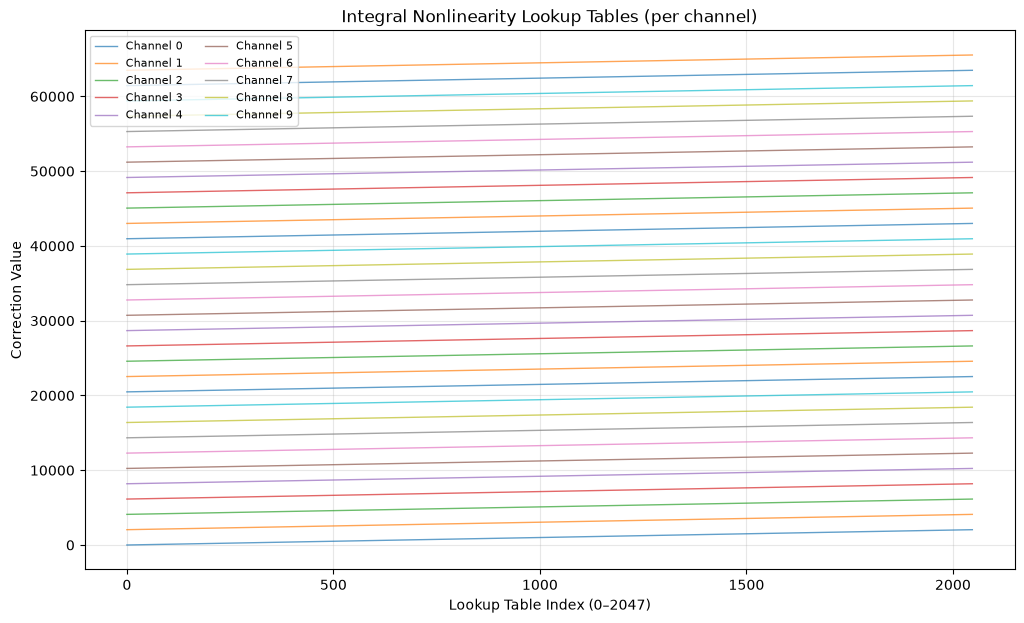

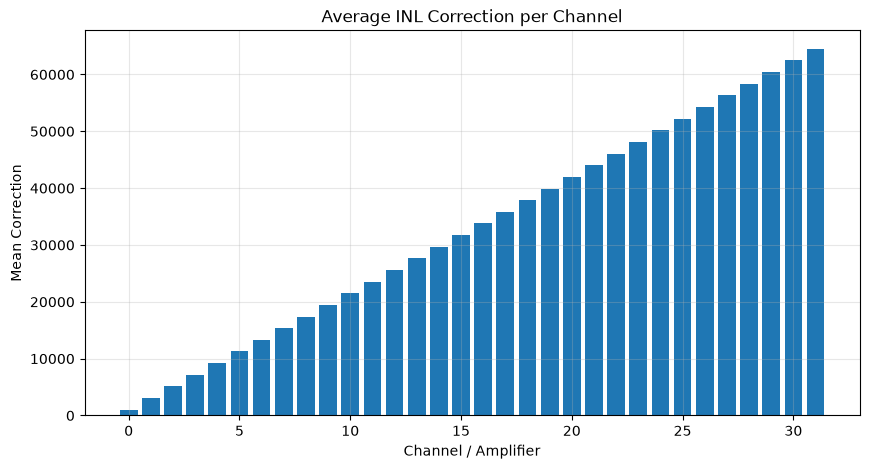

In [8]:
val = int_lin.value.flatten()

plt.figure(figsize=(12, 7))

# Plot all channels
for ch in range(32):
    start = ch * 2048
    end = start + 2048
    plt.plot(val[start:end], label=f'Channel {ch}' if ch < 10 else "", alpha=0.7, lw=1)

plt.title('Integral Nonlinearity Lookup Tables (per channel)')
plt.xlabel('Lookup Table Index (0–2047)')
plt.ylabel('Correction Value')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.show()

# Per-channel mean or statistics
means = [val[ch*2048:(ch+1)*2048].mean() for ch in range(32)]
plt.figure(figsize=(10, 5))
plt.bar(range(32), means)
plt.title('Average INL Correction per Channel')
plt.xlabel('Channel / Amplifier')
plt.ylabel('Mean Correction')
plt.grid(True, alpha=0.3)
plt.show()

## About this Notebook
**Author:** R. Diaz

**Updated On:** 2026-07-06

<table width="100%" style="border:none; border-collapse:collapse;">

  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>